# Сложность текста по ступеням обучения

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SergeyShk/ruTS/blob/master/examples/02_text_complexity_by_grade.ipynb)

Набор [`TextsByGrade`](https://sergeyshk.github.io/ruTS/datasets/textsbygrade/) - 68 текстов проекта [Plain Russian Language](https://github.com/infoculture/plainrussian) с меткой класса от 1 (сказки) до 17 (законы и регламенты). На нём подбирались коэффициенты формул удобочитаемости для русского языка, а здесь он служит одной осью «сложность», на которую по очереди накладываются все группы статистик [ruTS](https://github.com/SergeyShk/ruTS): какие формулы удобочитаемости и с какими коэффициентами лучше согласуются с меткой, растёт ли с классом лексическое разнообразие и лексическая сложность, что происходит с синтаксисом, морфологией и связностью. В конце - проверка на независимом наборе: хрестоматия для первого класса [`SovChLit`](https://sergeyshk.github.io/ruTS/datasets/sovchlit/).

Мера согласия везде одна - ранговая корреляция Спирмена ρ статистики с меткой класса; для формул, выдающих класс, дополнительно средняя абсолютная ошибка в классах.

## Установка и данные

В Colab ячейка ставит библиотеку и модель spaCy `ru_core_news_sm`; в окружении, где они уже есть, ничего не делает. Набор данных и частотный словарь загружаются один раз.

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("ruts") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ruts"], check=True)
if importlib.util.find_spec("ru_core_news_sm") is None:
    subprocess.run(
        [sys.executable, "-m", "spacy", "download", "ru_core_news_sm", "-q"], check=True
    )

In [2]:
import pandas as pd

from ruts.datasets import FreqDict, TextsByGrade

tbg = TextsByGrade()
tbg.download()
FreqDict().download()

records = list(tbg.get_records())
grades = pd.Series([record["grade"] for record in records], name="grade")
grades.value_counts().sort_index().to_frame("текстов").T

grade,1,3,4,5,6,7,8,9,10,11,12,15,17
текстов,11,3,7,1,4,2,3,2,3,15,1,1,15


Метки 1-11 - классы школы, 12 - статья Википедии (первый курс вуза), 15 - газетная статья, 17 - нормативные документы. Для графиков по группам метки объединены в четыре ступени: начальная школа (1-4), средняя (5-9), старшая (10-12) и «взрослые» тексты (15-17).

In [3]:
BANDS = [0, 4, 9, 12, 17]
BAND_LABELS = ["1-4", "5-9", "10-12", "15-17"]
bands = pd.cut(grades, BANDS, labels=BAND_LABELS)
bands.value_counts().sort_index().to_frame("текстов").T

grade,1-4,5-9,10-12,15-17
текстов,21,12,19,16


## Один проход spaCy - все статистики

Компоненты ruTS подключаются к пайплайну spaCy, и `nlp.pipe` за один проход считает по каждому тексту базовые статистики, удобочитаемость, лексическое разнообразие, морфологию, стиль, синтаксис, связность и лексическую сложность. Из объектов в `doc._` собирается одна таблица признаков; дальше все разделы работают с ней.

In [4]:
import spacy

from ruts import ReadabilityStats

nlp = spacy.load("ru_core_news_sm")
for name in ("basic", "readability", "diversity", "morph"):
    nlp.add_pipe(name, last=True)
for name in ("style", "syntax", "cohesion", "lexical"):
    nlp.add_pipe(name, last=True)

rows = []
for record, doc in zip(records, nlp.pipe(record["text"] for record in records), strict=True):
    row = {"grade": record["grade"], "n_words": doc._.basic.n_words}
    row.update({f"r_{key}": value for key, value in doc._.readability.get_stats().items()})
    row["r_sis_grade_by_freq"] = doc._.readability.sis_grade_by_freq(
        doc._.lexical.mean_ipm_content
    )
    # Те же формулы с другими пресетами коэффициентов - на уже посчитанном BasicStats
    for preset in ("fiction", "academic"):
        row[f"r_consensus_{preset}"] = ReadabilityStats(doc._.basic, preset=preset).consensus_grade
    row.update({f"d_{key}": value for key, value in doc._.diversity.get_stats().items()})
    row["d_mtld_windowed"] = doc._.diversity.windowed("mtld", window_len=100).mean
    row.update({f"l_{key}": value for key, value in doc._.lexical.get_stats().items()})
    row.update({f"st_{key}": value for key, value in doc._.style.get_stats().items()})
    row.update({f"s_{key}": value for key, value in doc._.syntax.get_stats().items()})
    row.update({f"c_{key}": value for key, value in doc._.cohesion.get_stats().items()})
    pos = doc._.morph.get_stats("pos")["pos"]
    n_pos = sum(pos.values())
    for tag in ("NOUN", "ADJ", "VERB", "PRON", "PART", "SCONJ", "CCONJ"):
        row[f"m_{tag}"] = pos.get(tag, 0) / n_pos
    rows.append(row)

df = pd.DataFrame(rows)
df["band"] = bands.to_numpy()
df.shape

(68, 136)

In [5]:
from scipy.stats import spearmanr


def correlations(columns: list[str]) -> pd.Series:
    """ρ Спирмена признаков с меткой класса"""
    values = {
        column: spearmanr(df[column], df["grade"], nan_policy="omit").statistic
        for column in columns
    }
    return pd.Series(values, name="ρ").sort_values(ascending=False)

## Удобочитаемость

Все одиннадцать формул согласуются с меткой на уровне ρ = 0.75-0.82; индекс Флеша считает в обратную сторону (чем выше, тем легче), поэтому его ρ отрицательный. Сводный класс - медиана формул, выдающих класс, - держится на 0.81. Разница между формулами меньше, чем разброс текстов внутри одного класса.

In [6]:
from ruts.constants import READABILITY_STATS_DESC

readability = correlations([f"r_{key}" for key in READABILITY_STATS_DESC if key != "reading_time"])
readability.index = [READABILITY_STATS_DESC[key.removeprefix("r_")] for key in readability.index]
readability.round(2).to_frame()

,ρ
Индекс Дейла-Чейла,0.82
Индекс SMOG,0.81
Сводный класс,0.81
Индекс Ганнинга,0.80
Индекс удобочитаемости LIX,0.80
Автоматический индекс удобочитаемости,0.80
Тест Флеша-Кинкайда,0.79
Индекс Колман-Лиау,0.78
Индекс удобочитаемости RIX,0.78
"Формула Соловьёва, Иванова, Солнышкиной",0.77


Корреляция не говорит, попадает ли формула в класс по величине. Для формул, выдающих номер класса, ниже средняя абсолютная ошибка в классах и медиана по всем текстам: ошибки в 3-4 класса - норма для формул по длинам слов и предложений, потому что метки идут через один (1, 3, 4, ...) и обрываются на 17, а тексты внутри класса очень разные. Индекс Колман-Лиау точнее остальных по величине, хотя по рангам не лучше.

In [7]:
from ruts.constants import READABILITY_GRADE_STATS

grade_like = ["consensus_grade", *READABILITY_GRADE_STATS, "sis_grade_by_freq"]
calibration = pd.DataFrame(
    {
        "ρ": [spearmanr(df[f"r_{key}"], df["grade"]).statistic for key in grade_like],
        "MAE, классов": [(df[f"r_{key}"] - df["grade"]).abs().mean() for key in grade_like],
        "медиана": [df[f"r_{key}"].median() for key in grade_like],
    },
    index=[READABILITY_STATS_DESC.get(key, "СИС с частотностью") for key in grade_like],
)
calibration.round(2)

,ρ,"MAE, классов",медиана
Сводный класс,0.81,3.72,6.75
Тест Флеша-Кинкайда,0.79,4.13,6.05
Индекс Колман-Лиау,0.78,2.98,6.30
Индекс SMOG,0.81,4.15,8.08
Автоматический индекс удобочитаемости,0.80,4.01,6.37
"Формула Соловьёва, Иванова, Солнышкиной",0.77,4.93,4.71
Индекс Дейла-Чейла,0.82,3.89,7.49
Индекс Ганнинга,0.80,4.14,8.82
СИС с частотностью,0.76,4.74,5.71


Сводный класс против метки: точки лежат вдоль диагонали, но с широким коридором - у первого класса разброс от 0.5 до 5.5, у 11-го от 3 до 13, у документов (17) от 12.5 до 39.5. Формулы отличают ступени, а не соседние классы.

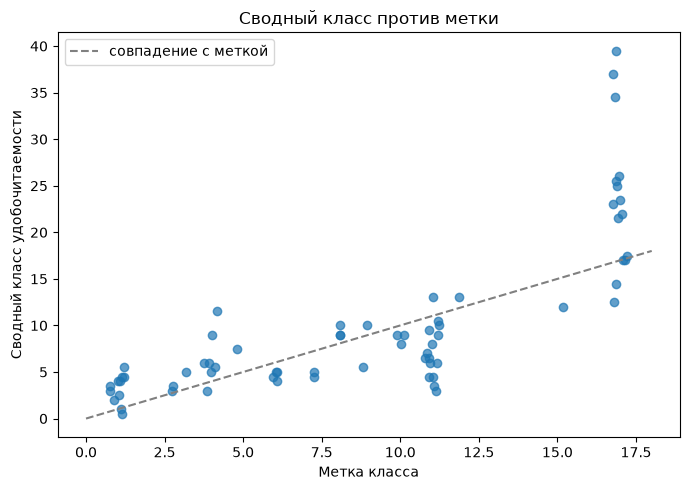

In [8]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(0)
jitter = rng.uniform(-0.25, 0.25, len(df))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["grade"] + jitter, df["r_consensus_grade"], alpha=0.7)
ax.plot([0, 18], [0, 18], linestyle="--", color="gray", label="совпадение с меткой")
ax.set_xlabel("Метка класса")
ax.set_ylabel("Сводный класс удобочитаемости")
ax.set_title("Сводный класс против метки")
ax.legend()
fig.tight_layout()

### Пресеты коэффициентов

Коэффициенты формул задаются пресетом `preset`: `plainrussian` (по умолчанию) подобран как раз на этом наборе, `fiction` - коэффициенты Оборневой для художественных текстов, `academic` - казанской группы для учебных. По рангам пресеты неотличимы (0.81-0.83), по величине `academic` чуть точнее, `fiction` завышает класс документов. Сравнивать пресеты на наборе, где один из них подбирался, - нечестно в его пользу, поэтому вывод скромный: коэффициенты меняют шкалу, а не порядок текстов.

In [9]:
presets = {
    "plainrussian": "r_consensus_grade",
    "fiction": "r_consensus_fiction",
    "academic": "r_consensus_academic",
}
pd.DataFrame(
    {
        "ρ": [spearmanr(df[column], df["grade"]).statistic for column in presets.values()],
        "MAE, классов": [(df[column] - df["grade"]).abs().mean() for column in presets.values()],
        "медиана": [df[column].median() for column in presets.values()],
    },
    index=list(presets),
).round(2)

,ρ,"MAE, классов",медиана
plainrussian,0.81,3.72,6.75
fiction,0.83,3.76,7.75
academic,0.82,3.57,7.25


## Лексика: разнообразие против сложности

Лексическое разнообразие с классом не связано: MTLD, HD-D, MATTR и остальные меры `DiversityStats` дают ρ около нуля - сказка для первого класса и закон одинаково не повторяют слова, просто по разным причинам. Лексическая сложность по частотному словарю ведёт себя иначе: с классом растут лексическая плотность (доля знаменательных слов) и доля слов из топ-5000 словаря, а доля слов вне топ-10000 падает. Последнее выглядит парадоксом, но объясняется составом текстов: у сказок и детской прозы редкие слова - это имена, уменьшительные формы и просторечие, а у документов лексика формальная и частотная, сложность в них создаёт не словарь, а синтаксис.

In [10]:
from ruts.constants import DIVERSITY_STATS_DESC, LEXICAL_STATS_DESC

diversity = correlations(
    ["d_mtld", "d_mtld_windowed", "d_hdd", "d_mattr", "d_yule_k", "d_entropy"]
)
diversity.index = [
    DIVERSITY_STATS_DESC.get(key.removeprefix("d_"), "MTLD по окнам в 100 слов")
    for key in diversity.index
]
lexical = correlations([f"l_{key}" for key in LEXICAL_STATS_DESC])
lexical.index = [LEXICAL_STATS_DESC[key.removeprefix("l_")] for key in lexical.index]
pd.concat([diversity, lexical]).round(2).to_frame()

,ρ
MTLD по окнам в 100 слов,0.05
Характеристика Юла (Yule's K),0.04
Hypergeometric Distribution D (HD-D),-0.00
Measure of Textual Lexical Diversity (MTLD),-0.00
Moving Average Type-Token Ratio (MATTR),-0.02
Энтропия Шеннона (бит),-0.23
Доля слов из топ-5000,0.50
Лексическая плотность,0.50
Доля слов из топ-10000,0.47
Средняя логарифмическая частотность знаменательных слов,0.47


## Синтаксис и морфология

Здесь связь с классом сильнее всего после самих формул удобочитаемости. Растут именная нагрузка (модификаторов на именную группу, отношение существительных к глаголам, доля прилагательных), длина клаузы и глубина дерева, доля пассива, причастные обороты, расщеплённые сказуемые, цепочки родительных падежей; из лексических маркеров канцелярита - отглагольные существительные и производные предлоги. Падают доля глаголов, частиц и местоимений - приметы устной, разговорной речи детских текстов. Число клауз на предложение с классом не растёт: длинные предложения документов - это не придаточные, а распространённые именные группы.

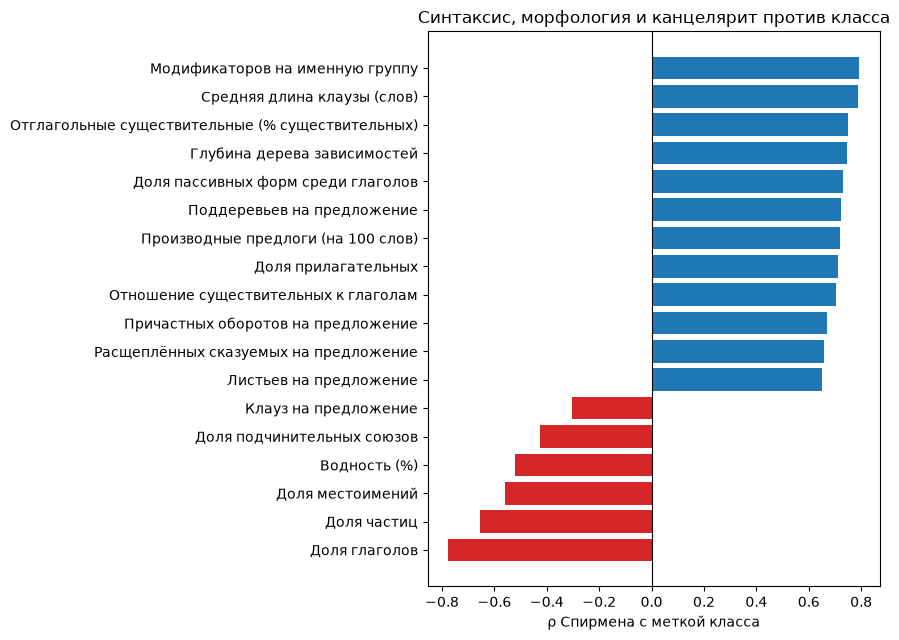

In [11]:
from ruts.constants import STYLE_STATS_DESC, SYNTAX_STATS_DESC

POS_DESC = {
    "m_NOUN": "Доля существительных",
    "m_ADJ": "Доля прилагательных",
    "m_VERB": "Доля глаголов",
    "m_PRON": "Доля местоимений",
    "m_PART": "Доля частиц",
    "m_SCONJ": "Доля подчинительных союзов",
    "m_CCONJ": "Доля сочинительных союзов",
}
syntax_columns = [f"s_{key}" for key in SYNTAX_STATS_DESC]
style_columns = ["st_verbal_nouns", "st_compound_prepositions", "st_water"]
syntax = correlations([*syntax_columns, *style_columns, *POS_DESC])


def describe(column: str) -> str:
    prefix, key = column.split("_", 1)
    return {"s": SYNTAX_STATS_DESC, "st": STYLE_STATS_DESC}.get(prefix, POS_DESC).get(
        key if prefix != "m" else column, column
    )


syntax.index = [describe(column) for column in syntax.index]
strongest = pd.concat([syntax.head(12), syntax.tail(6)])

fig, ax = plt.subplots(figsize=(9, 6.5))
colors = ["tab:red" if value < 0 else "tab:blue" for value in strongest]
ax.barh(strongest.index[::-1], strongest.to_numpy()[::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("ρ Спирмена с меткой класса")
ax.set_title("Синтаксис, морфология и канцелярит против класса")
fig.tight_layout()

По ступеням обучения те же признаки видны как распределения: глубина дерева и доля пассива растут от ступени к ступени, доля глаголов падает, лексическая плотность делает скачок на «взрослых» текстах. Видно и то, что стоит за высокими корреляциями: главный контраст - между художественной прозой школьной программы и документами, а внутри школы ступени различаются заметно меньше и с перекрытием.

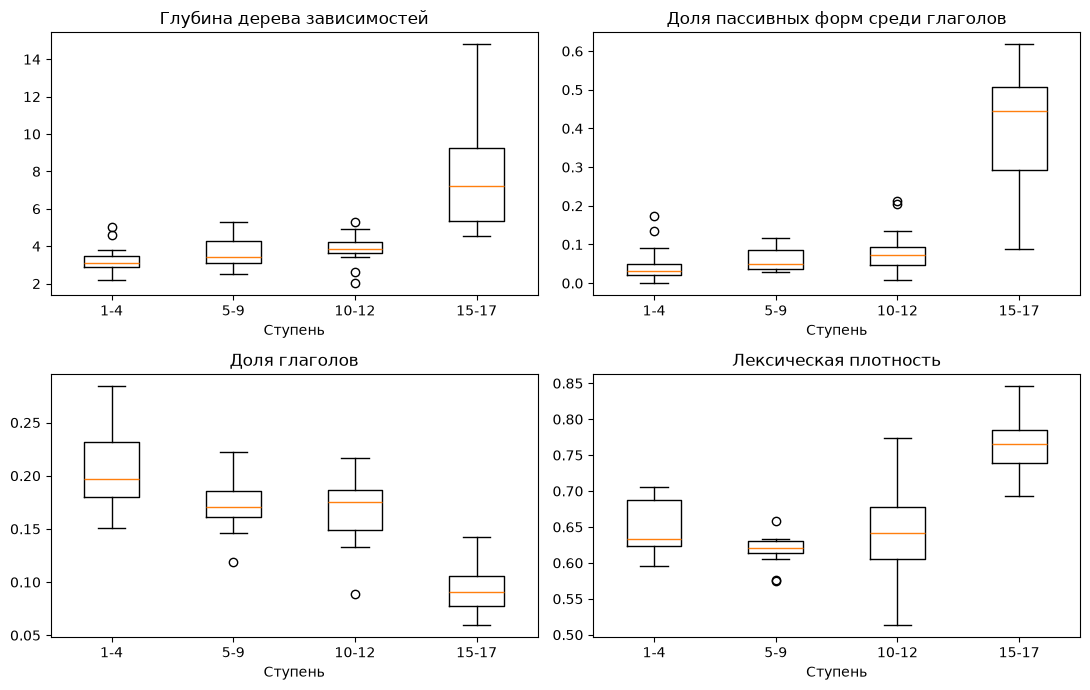

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
panels = [
    ("s_tree_depth", "Глубина дерева зависимостей"),
    ("s_p_passive", "Доля пассивных форм среди глаголов"),
    ("m_VERB", "Доля глаголов"),
    ("l_lexical_density", "Лексическая плотность"),
]
for ax, (column, title) in zip(axes.flat, panels, strict=True):
    ax.boxplot([df.loc[df["band"] == band, column].dropna() for band in BAND_LABELS])
    ax.set_xticks(range(1, len(BAND_LABELS) + 1), BAND_LABELS)
    ax.set_title(title)
    ax.set_xlabel("Ступень")
fig.tight_layout()

## Связность

Статистики связности `CohesionStats` с классом связаны слабее и в основном отрицательно: плотность коннекторов на 1000 слов, особенно противительных («но», «а», «однако»), и доля местоимений падают - повествование для детей держится на «а потом», «но вдруг» и «он», документ - на повторе терминов. Повтор знаменательных слов между всеми парами предложений с классом растёт по той же причине.

In [13]:
from ruts.constants import COHESION_STATS_DESC

cohesion = correlations([f"c_{key}" for key in COHESION_STATS_DESC])
cohesion.index = [COHESION_STATS_DESC[key.removeprefix("c_")] for key in cohesion.index]
pd.concat([cohesion.head(5), cohesion.tail(5)]).round(2).to_frame()

,ρ
Вторичных коннекторов на 1000 слов,0.53
Повтор знаменательных слов во всех парах предложений,0.48
Повтор аргументов во всех парах предложений,0.46
Повтор существительных во всех парах предложений,0.43
Повтор знаменательных слов в соседних предложениях,0.40
Коннекторов на 1000 слов,-0.41
Первичных коннекторов на 1000 слов,-0.48
Доля местоимений,-0.49
Отношение местоимений к существительным,-0.50
Противительных коннекторов на 1000 слов,-0.66


## Проверка на независимом наборе

`SovChLit` - хрестоматия «Родная речь» для первого класса (1963), 179 текстов, которые при подборе коэффициентов не участвовали. Если формулы что-то измеряют, сводный класс для них должен лечь в начальную школу. Тексты короче 50 слов отброшены: на пяти-десяти словах формулы по длине предложения не работают.

In [14]:
from ruts import BasicStats
from ruts.datasets import SovChLit

sc = SovChLit()
sc.download()
reader = []
for record in sc.get_records():
    bs = BasicStats(record["text"])
    if bs.n_words < 50:
        continue
    rs = ReadabilityStats(bs)
    reader.append(
        {
            "subject": record["subject"],
            "type": record["type"],
            "n_words": bs.n_words,
            "words_per_sent": bs.n_words / bs.n_sents,
            "consensus_grade": rs.consensus_grade,
            "describe": rs.describe_grade(),
        }
    )
reader = pd.DataFrame(reader)
print(len(reader), "текстов, медиана сводного класса", reader["consensus_grade"].median())
print("доля текстов с классом не выше 4:", round((reader["consensus_grade"] <= 4).mean(), 2))
reader["describe"].value_counts().to_frame("текстов")

115 текстов, медиана сводного класса 2.5
доля текстов с классом не выше 4: 0.79


,текстов
describe,
1-3-й класс (6-8 лет),75
4-6-й класс (9-11 лет),35
7-9-й класс (12-14 лет),5


Самые «сложные» по формулам тексты хрестоматии - не басни (у трёх басен 4.5-5), а рассказы с предложениями по 15-17 слов: формулы видят длину предложения, а не жанр.

In [15]:
reader.sort_values("consensus_grade", ascending=False).head(5).round(1)

,subject,type,n_words,words_per_sent,consensus_grade,describe
62,Лиса Патрикеевна,Рассказ,86,17.2,9.0,7-9-й класс (12-14 лет)
85,Уточки,Рассказ,78,15.6,7.5,7-9-й класс (12-14 лет)
70,Три медведя II,Сказка,207,15.9,7.0,7-9-й класс (12-14 лет)
0,Как учился В. И. Ленин,Рассказ,136,17.0,6.5,7-9-й класс (12-14 лет)
20,Ай да мороз!,Рассказ,50,10.0,6.5,7-9-й класс (12-14 лет)


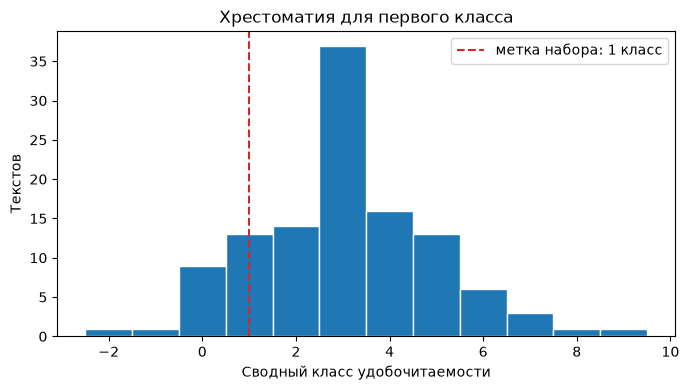

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(reader["consensus_grade"], bins=np.arange(-2.5, 10.5, 1), edgecolor="white")
ax.axvline(1, color="tab:red", linestyle="--", label="метка набора: 1 класс")
ax.set_xlabel("Сводный класс удобочитаемости")
ax.set_ylabel("Текстов")
ax.set_title("Хрестоматия для первого класса")
ax.legend()
fig.tight_layout()

Медиана 2.5, четыре текста из пяти не выше 4 класса. Формулы, подобранные на одном наборе, переносятся на другой с той же точностью «в ступень».

## Итоги

*   Все формулы удобочитаемости согласуются с меткой на ρ = 0.75-0.82, сводный класс - 0.81; ошибка по величине 3-4 класса - предел для формул по длинам слов и предложений. Пресеты коэффициентов меняют шкалу, не порядок.
*   Лексическое разнообразие сложность не измеряет (ρ ≈ 0); лексическая сложность по частотному словарю - частично (плотность, полосы), с оговоркой про имена и уменьшительные формы в детских текстах.
*   Сильнее всего после формул с классом связан синтаксис: именная нагрузка, длина клаузы, глубина дерева, пассив, обороты, цепочки родительных - и морфология (доля глаголов и частиц падает). Это признаки, которых нет в классических формулах; оговорка - большую часть связи даёт контраст прозы с документами, внутри школьной программы ступени перекрываются.
*   Связность с классом связана отрицательно: детская проза держится на коннекторах и местоимениях, документ - на повторе терминов.
*   На независимой хрестоматии для первого класса медиана сводного класса 2.5.

Дальше: [сквозной разбор одного текста](01_text_walkthrough.ipynb) - если нужен обзор всех инструментов, и [документация](https://sergeyshk.github.io/ruTS/) с формулами и источниками.